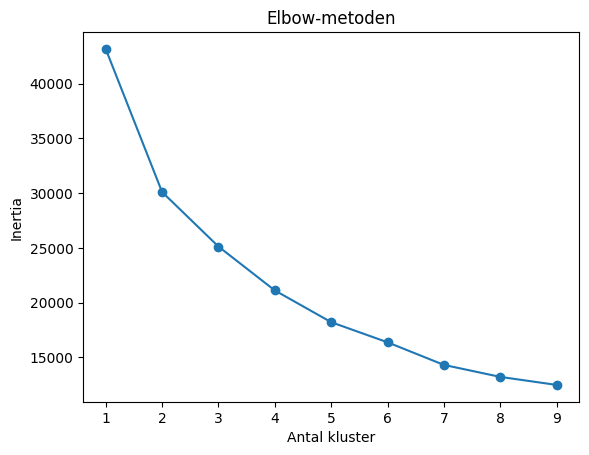

             BALANCE     PURCHASES  CASH_ADVANCE  CREDIT_LIMIT      PAYMENTS
Cluster                                                                     
0        6004.239828    960.599101   5807.195620   9562.540253   5118.996678
1         817.763476    515.708270    489.907381   2626.640448    917.224230
2        5259.703654  22374.832703   1151.838978  15624.324324  23947.833531
3        2245.840822   2184.922805    708.343067   8143.884424   2732.947733


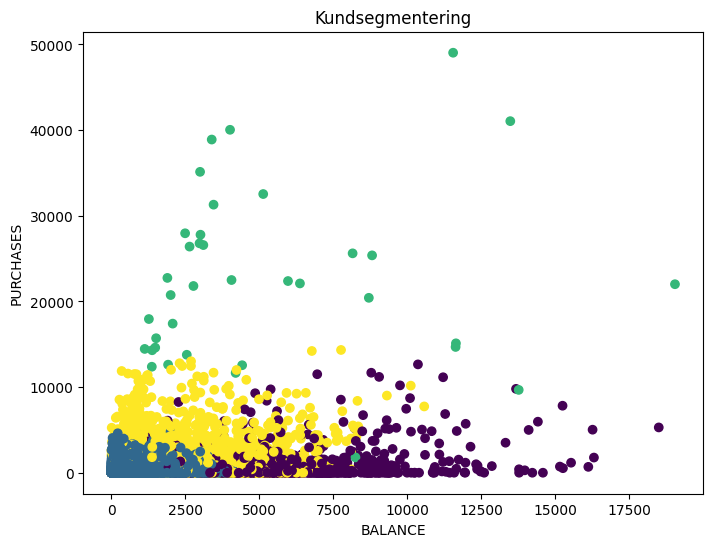

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


df = pd.read_csv("bank_data.csv")

df = df.dropna()


features = [
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS"
]

X = df[features]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Antal kluster")
plt.ylabel("Inertia")
plt.title("Elbow-metoden")
plt.show()


kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)


print(df.groupby("Cluster")[features].mean())


plt.figure(figsize=(8,6))
plt.scatter(df["BALANCE"], df["PURCHASES"], c=df["Cluster"], cmap='viridis')
plt.xlabel("BALANCE")
plt.ylabel("PURCHASES")
plt.title("Kundsegmentering")
plt.show()


df.to_csv("bank_clustered.csv", index=False)